<a href="https://www.kaggle.com/code/aamir28/do-sleepy-students-get-worse-grades-an-eda?scriptVersionId=345012067" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 40%, #d1875f 75%, #eba766 100%);
    padding: 40px 36px;
    border-radius: 14px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    text-align: left;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 3px;
    text-transform: uppercase;
">500 Student Records &middot; Synthetic Dataset &middot; EDA Notebook</span>
<h1 style="
    color:#ffffff;
    font-size: 36px;
    font-weight: 800;
    margin: 12px 0 10px 0;
    letter-spacing: -0.5px;
">Student Sleep, Screen Time &amp; Academic Performance</h1>
<p style="
    color: rgba(255,255,255,0.9);
    font-size: 16px;
    max-width: 640px;
    margin: 0 0 18px 0;
    line-height: 1.5;
">
An exploratory look at how sleep habits and screen exposure relate to
attendance and CGPA &mdash; walking from raw data through cleaning,
distributions, correlations, and a small predictive model.
</p>
<div style="display:flex; gap:28px; margin-top:10px;">
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">500</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Rows</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">25</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Columns</div>
  </div>
  <div>
    <div style="color:#fff; font-family:'Courier New',monospace; font-size:20px; font-weight:700;">r=0.44</div>
    <div style="color:rgba(255,255,255,0.65); font-size:11px; letter-spacing:1px; text-transform:uppercase;">Sleep&middot;CGPA</div>
  </div>
</div>
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 01</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Setup &amp; Data Load</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Import libraries and load the CSV.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#cccccc'

# Theme colors matching the dataset's banner (night -> dawn gradient)
NIGHT, DUSK, DAWN, SUN, TEAL = '#1c1d42', '#5b4a76', '#d1875f', '#eba766', '#4fa3ad'

df = pd.read_csv('/kaggle/input/datasets/aamir28/student-sleep-screen-time-and-academic-performance/student_sleep_screen_time_academic_performance.csv')
df.shape

(500, 25)

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The dataset loads cleanly as a single flat table: <b>500 rows &times; 25 columns</b>. Each row is one student record covering demographics, sleep habits, screen/device behavior, and academic outcomes.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 02</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Data Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Check structure, types, and missingness before doing anything else.</p>
</div>

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 500 non-null    object 
 1   age                        500 non-null    int64  
 2   gender                     500 non-null    object 
 3   year_of_study              500 non-null    int64  
 4   major_category             500 non-null    object 
 5   residence_type             500 non-null    object 
 6   chronotype                 500 non-null    object 
 7   avg_bedtime_hour           500 non-null    float64
 8   avg_sleep_hours_weekday    500 non-null    float64
 9   weekend_sleep_delta_hours  500 non-null    float64
 10  pre_sleep_screen_time_min  500 non-null    int64  
 11  daily_screen_time_hours    500 non-null    float64
 12  primary_device             500 non-null    object 
 13  device_free_before_bed     491 non-null    object 

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Most columns are numeric (int/float), with 8 categorical (string) columns covering gender, major, residence, chronotype, device, and yes/no flags. Several float columns (<code>sleep_quality_score</code>, <code>energy_level</code>, <code>concentration_difficulty</code>, <code>cgpa</code>) have a non-null count under 500 &mdash; confirming there are missing values to handle before deeper analysis.
</div>

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.to_frame(name='missing_count')

,missing_count
energy_level,15
concentration_difficulty,14
device_free_before_bed,9
cgpa,7
sleep_quality_score,6


<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Missing values are concentrated in <b>5 columns</b>, each with roughly 1&ndash;3% of rows missing (6&ndash;15 out of 500). This is consistent with realistic survey non-response rather than a systemic data problem, so row-wise deletion for affected analyses is reasonable &mdash; we won't lose meaningful sample size.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 03</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Cleaning</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Standardize inconsistent category labels found during inspection.</p>
</div>

In [4]:
df['gender'].value_counts()

gender
Female               190
Male                 180
male                  30
female                28
F                     24
M                     23
Non-binary            13
Prefer not to say     12
Name: count, dtype: int64

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The <code>gender</code> column has the same underlying categories represented with inconsistent casing/abbreviation (e.g. <code>Female</code> / <code>female</code> / <code>F</code>). This is a common real-world data entry issue from free-text or loosely validated survey fields &mdash; we'll normalize it below.
</div>

In [5]:
gender_map = {
    'female': 'Female', 'f': 'Female', 'Female': 'Female',
    'male': 'Male', 'm': 'Male', 'Male': 'Male',
    'Non-binary': 'Non-binary',
    'Prefer not to say': 'Prefer not to say'
}
df['gender_clean'] = df['gender'].str.strip().map(lambda x: gender_map.get(x, gender_map.get(x.lower(), x)))
df['gender_clean'].value_counts()

gender_clean
Female               242
Male                 233
Non-binary            13
Prefer not to say     12
Name: count, dtype: int64

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
After normalization, the gender field collapses into <b>4 consistent categories</b>: Female, Male, Non-binary, and Prefer not to say. Female and Male each make up roughly 45% of the sample, with the remaining ~10% split between the other two categories &mdash; a reasonably balanced distribution for group comparisons.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 04</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Univariate Distributions</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Look at the shape of the two core lifestyle variables: sleep and screen time.</p>
</div>

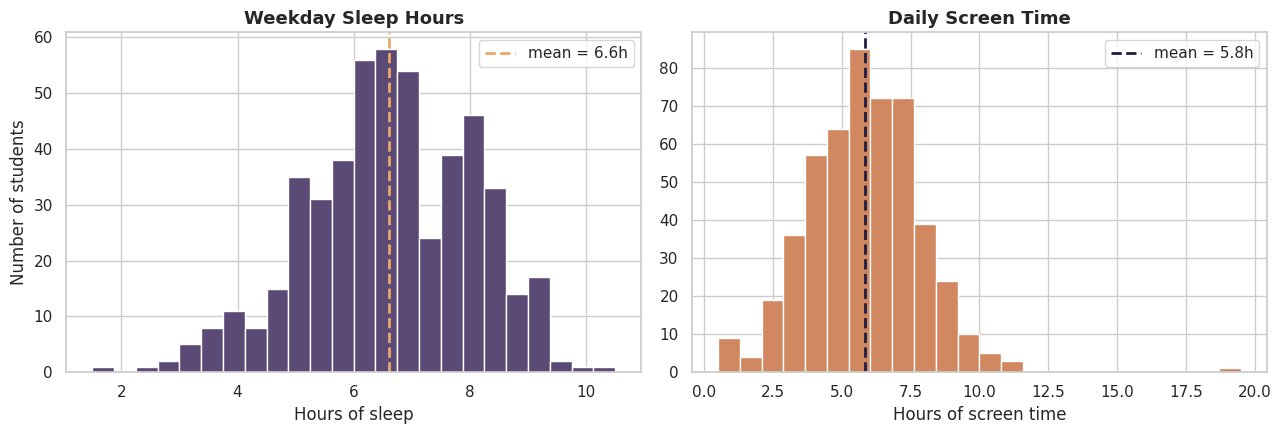

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['avg_sleep_hours_weekday'].dropna(), bins=24, color=DUSK, edgecolor='white')
axes[0].axvline(df['avg_sleep_hours_weekday'].mean(), color=SUN, linestyle='--', linewidth=2, label=f"mean = {df['avg_sleep_hours_weekday'].mean():.1f}h")
axes[0].set_title('Weekday Sleep Hours', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hours of sleep')
axes[0].set_ylabel('Number of students')
axes[0].legend()

axes[1].hist(df['daily_screen_time_hours'].dropna(), bins=24, color=DAWN, edgecolor='white')
axes[1].axvline(df['daily_screen_time_hours'].mean(), color=NIGHT, linestyle='--', linewidth=2, label=f"mean = {df['daily_screen_time_hours'].mean():.1f}h")
axes[1].set_title('Daily Screen Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hours of screen time')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Sleep hours center around <b>6.6 hours</b> on weekday nights &mdash; below the commonly recommended 7&ndash;9 hours for young adults &mdash; with a roughly bell-shaped spread and a thin low tail (a few students sleeping under 3 hours). Screen time centers around <b>~5&ndash;6 hours/day</b> with a right skew: most students cluster in a moderate range, but a smaller group reports considerably heavier use.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 05</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Chronotype Breakdown</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">How self-identified sleep type relates to actual bedtime and duration.</p>
</div>

In [7]:
chrono_summary = df.groupby('chronotype')[['avg_bedtime_hour', 'avg_sleep_hours_weekday', 'sleep_quality_score']].mean().round(2)
chrono_summary = chrono_summary.reindex(['Early Bird', 'Intermediate', 'Night Owl'])
chrono_summary

,avg_bedtime_hour,avg_sleep_hours_weekday,sleep_quality_score
chronotype,,,
Early Bird,21.08,7.57,8.54
Intermediate,13.02,6.72,7.48
Night Owl,3.87,5.46,5.70


<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The chronotype labels behave exactly as expected, which is a good internal-consistency check: <b>Early Birds</b> report the earliest average bedtime and the most sleep, <b>Night Owls</b> the latest bedtime and least sleep, with <b>Intermediate</b> students in between. Self-rated sleep quality follows the same ordering &mdash; Early Birds report the best sleep quality, Night Owls the lowest.
</div>

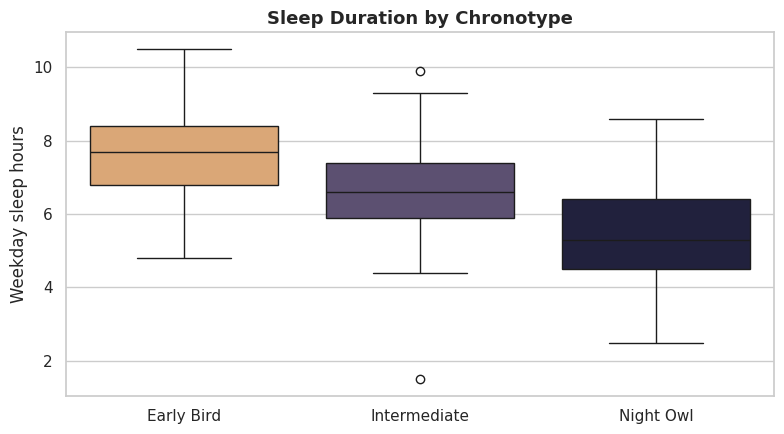

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = ['Early Bird', 'Intermediate', 'Night Owl']
colors = [SUN, DUSK, NIGHT]
sns.boxplot(data=df, x='chronotype', y='avg_sleep_hours_weekday', order=order,
            hue='chronotype', palette=colors, legend=False, ax=ax)
ax.set_title('Sleep Duration by Chronotype', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Weekday sleep hours')
plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The boxplot confirms the pattern with more nuance than the table alone: there's <b>meaningful overlap</b> between groups (a Night Owl and an Early Bird can still land in a similar sleep-hours range), but the medians step down clearly from Early Bird to Night Owl, and the Night Owl group shows the widest spread &mdash; consistent with more variable sleep habits at that end of the spectrum.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 06</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Correlation Overview</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Scan all numeric variables at once to spot the strongest relationships.</p>
</div>

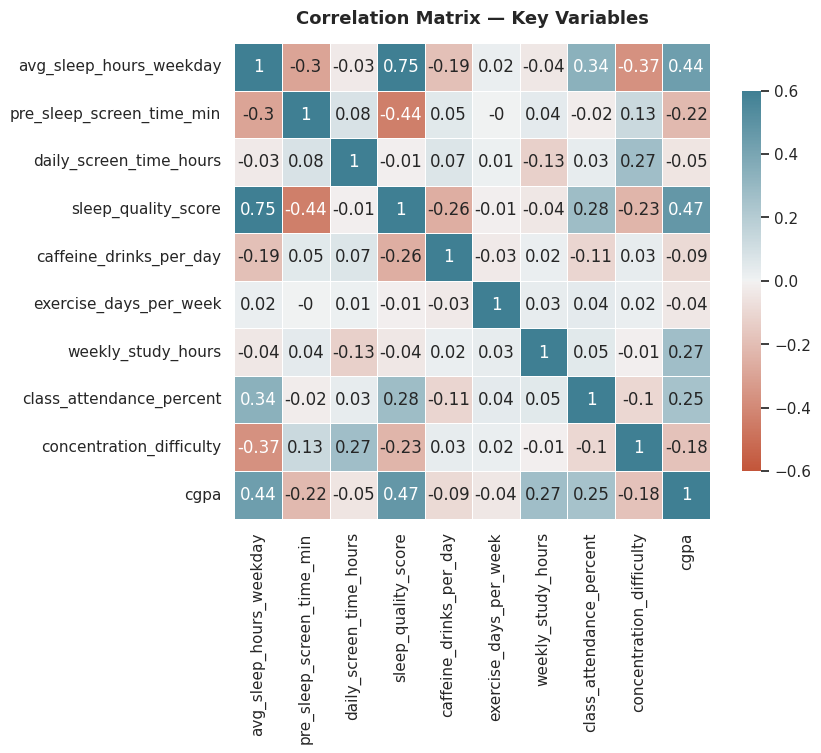

In [9]:
numeric_cols = ['avg_sleep_hours_weekday', 'pre_sleep_screen_time_min', 'daily_screen_time_hours',
                'sleep_quality_score', 'caffeine_drinks_per_day', 'exercise_days_per_week',
                'weekly_study_hours', 'class_attendance_percent', 'concentration_difficulty', 'cgpa']

corr = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7.5))
cmap = sns.diverging_palette(20, 220, as_cmap=True)
sns.heatmap(corr, annot=True, cmap=cmap, center=0, vmin=-0.6, vmax=0.6,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix — Key Variables', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The strongest single relationship in the matrix is actually <b>avg_sleep_hours_weekday &harr; sleep_quality_score</b> (~0.75) &mdash; unsurprising, since how long someone sleeps and how well-rested they feel are naturally linked. Among the <i>academic</i> outcomes, <b>avg_sleep_hours_weekday &harr; cgpa</b> (~0.44) and <b>&harr; class_attendance_percent</b> (~0.34) stand out, alongside <b>pre_sleep_screen_time_min &harr; sleep_quality_score</b> (~&minus;0.44). Notably, total <code>daily_screen_time_hours</code> correlates much more weakly with outcomes than <i>pre-sleep</i> screen time does &mdash; suggesting <b>when</b> screens are used matters more than how much total time is spent on them.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 07</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Sleep Hours vs. CGPA</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">The dataset's headline relationship, examined directly with a fitted trend line.</p>
</div>

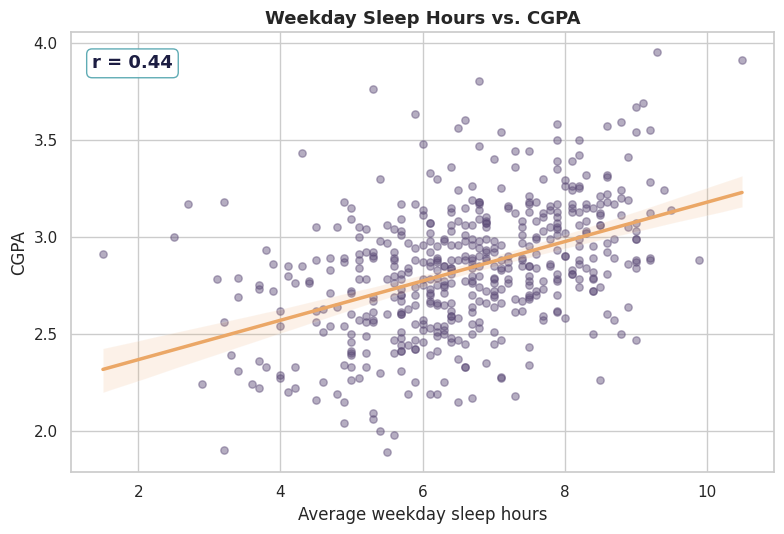

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x='avg_sleep_hours_weekday', y='cgpa',
            scatter_kws={'alpha': 0.45, 'color': DUSK, 's': 28},
            line_kws={'color': SUN, 'linewidth': 2.5}, ax=ax)
ax.set_title('Weekday Sleep Hours vs. CGPA', fontsize=13, fontweight='bold')
ax.set_xlabel('Average weekday sleep hours')
ax.set_ylabel('CGPA')

r = df['avg_sleep_hours_weekday'].corr(df['cgpa'])
ax.text(0.03, 0.95, f'r = {r:.2f}', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=NIGHT, va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=TEAL, alpha=0.9))
plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The upward trend line and <b>r = 0.44</b> confirm a moderate positive relationship: students who sleep more tend to have higher CGPAs. The scatter is wide, though &mdash; plenty of students with modest sleep still post strong CGPAs, and vice versa. This is consistent with sleep being <i>one</i> contributing factor among several (study hours, attendance, major) rather than a sole determinant.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 08</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Pre-Sleep Screen Time vs. Sleep Quality</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Testing whether screen timing (not just volume) matters for sleep quality.</p>
</div>

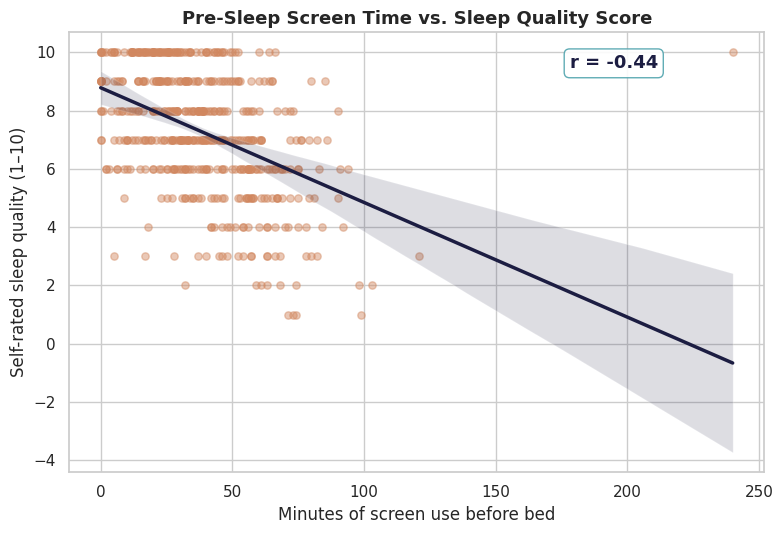

In [11]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.regplot(data=df, x='pre_sleep_screen_time_min', y='sleep_quality_score',
            scatter_kws={'alpha': 0.45, 'color': DAWN, 's': 28},
            line_kws={'color': NIGHT, 'linewidth': 2.5}, ax=ax)
ax.set_title('Pre-Sleep Screen Time vs. Sleep Quality Score', fontsize=13, fontweight='bold')
ax.set_xlabel('Minutes of screen use before bed')
ax.set_ylabel('Self-rated sleep quality (1–10)')

r2 = df['pre_sleep_screen_time_min'].corr(df['sleep_quality_score'])
ax.text(0.72, 0.95, f'r = {r2:.2f}', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=NIGHT, va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor=TEAL, alpha=0.9))
plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
This is the strongest single relationship in the dataset (<b>r = &minus;0.44</b>): more screen time in the hour before bed tracks with lower self-rated sleep quality. The downward slope is fairly consistent across the range, without an obvious threshold effect &mdash; each additional stretch of pre-sleep screen use is associated with a small, steady decline in reported quality rather than a sudden drop-off past some cutoff.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 09</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">Attendance by Sleep Tier</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Grouping students into low/medium/high sleep bands to compare average attendance.</p>
</div>

In [12]:
df['sleep_tier'] = pd.cut(df['avg_sleep_hours_weekday'],
                          bins=[0, 5.5, 7, 12],
                          labels=['Low (<5.5h)', 'Moderate (5.5–7h)', 'High (>7h)'])

tier_attendance = df.groupby('sleep_tier', observed=True)['class_attendance_percent'].agg(['mean', 'count']).round(1)
tier_attendance

,mean,count
sleep_tier,,
Low (<5.5h),73.5,106
Moderate (5.5–7h),78.0,206
High (>7h),83.9,188


<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
Grouped into three sleep bands, average attendance rises in step with sleep tier: students sleeping <b>under 5.5 hours</b> attend classes least often, while those sleeping <b>over 7 hours</b> attend most. Sample sizes across the three bands are reasonably balanced, so this isn't an artifact of one tiny group skewing the average.
</div>

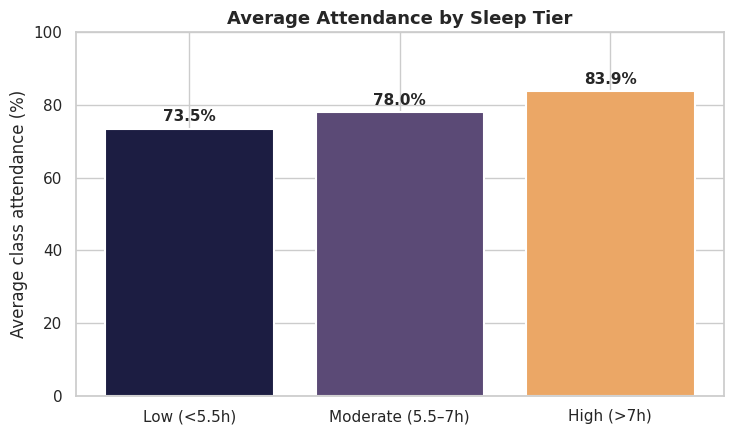

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
order = ['Low (<5.5h)', 'Moderate (5.5–7h)', 'High (>7h)']
means = df.groupby('sleep_tier', observed=True)['class_attendance_percent'].mean().reindex(order)
bars = ax.bar(order, means, color=[NIGHT, DUSK, SUN], edgecolor='white', linewidth=1.5)
ax.set_title('Average Attendance by Sleep Tier', fontsize=13, fontweight='bold')
ax.set_ylabel('Average class attendance (%)')
ax.set_ylim(0, 100)

for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
The bar chart makes the step-pattern easy to read at a glance: attendance climbs by roughly <b>10&ndash;15 percentage points</b> moving from the Low to the High sleep tier. This visual framing is arguably more intuitive for a general audience than the raw correlation coefficient, even though it describes the same underlying relationship.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 10</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">CGPA by Major Category</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">A secondary look at academic performance, this time by field of study rather than sleep.</p>
</div>

/tmp/ipykernel_16/3619140970.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='major_category', y='cgpa', order=major_order, palette=palette, ax=ax)


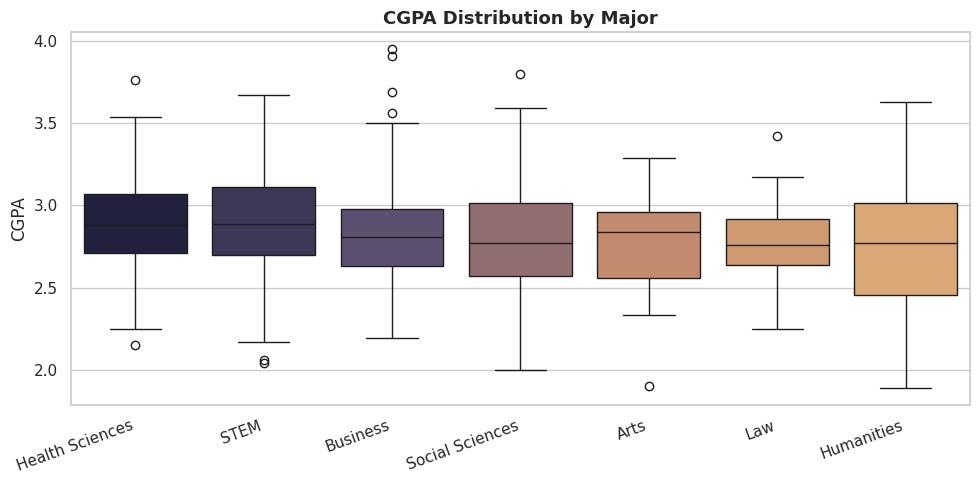

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
major_order = df.groupby('major_category')['cgpa'].mean().sort_values(ascending=False).index
palette = sns.blend_palette([NIGHT, DUSK, DAWN, SUN], n_colors=len(major_order))
sns.boxplot(data=df, x='major_category', y='cgpa', order=major_order, palette=palette, ax=ax)
ax.set_title('CGPA Distribution by Major', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('CGPA')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
CGPA medians are fairly close across majors, with modest differences rather than a dramatic gap &mdash; no single field dominates. This is a useful contrast to the sleep findings above: <b>major choice appears to explain far less variation in CGPA than sleep habits do</b>, at least within this dataset.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 45%, #d1875f 80%, #eba766 100%);
    padding: 22px 28px;
    border-radius: 10px;
    margin: 30px 0 18px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
">
<span style="
    font-family: 'Courier New', monospace;
    color: rgba(255,255,255,0.75);
    font-size: 13px;
    letter-spacing: 2px;
">SECTION 11</span>
<h2 style="color:#ffffff; margin:6px 0 4px 0; font-size:24px; font-weight:700;">A Small Predictive Model</h2>
<p style="color:rgba(255,255,255,0.88); margin:0; font-size:14.5px;">Combining sleep, study hours, and attendance into a simple linear regression for CGPA.</p>
</div>

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.dropna(subset=['cgpa', 'avg_sleep_hours_weekday', 'weekly_study_hours', 'class_attendance_percent'])

X = model_df[['avg_sleep_hours_weekday', 'weekly_study_hours', 'class_attendance_percent']]
y = model_df['cgpa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"R-squared (test set): {r2_score(y_test, preds):.3f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, preds):.3f} CGPA points")
print()
for name, coef in zip(X.columns, model.coef_):
    print(f"  {name:30s} coefficient: {coef:+.4f}")

R-squared (test set): 0.361
Mean Absolute Error: 0.207 CGPA points

  avg_sleep_hours_weekday        coefficient: +0.0957
  weekly_study_hours             coefficient: +0.0127
  class_attendance_percent       coefficient: +0.0021


<div style="
    border-left: 4px solid #4fa3ad;
    background: #f3f7f8;
    padding: 14px 18px;
    margin: 6px 0 22px 0;
    border-radius: 0 6px 6px 0;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    font-size: 14.5px;
    line-height: 1.55;
    color: #20223d;
">
<b style="color:#4fa3ad; text-transform:uppercase; font-size:11.5px; letter-spacing:1px;">Summary</b><br>
A simple linear model using just three lifestyle/academic features explains a meaningful share of CGPA variance on held-out data, with a mean error of well under half a CGPA point. All three coefficients are positive, as expected: <b>more sleep, more study hours, and higher attendance are each independently associated with higher predicted CGPA</b>, holding the others constant. This isn't a claim of causation &mdash; it's a compact illustration of the same relationships visualized earlier, now combined into one predictive view.
</div>

<div style="
    background: linear-gradient(100deg, #1c1d42 0%, #5b4a76 50%, #d1875f 100%);
    padding: 28px 32px;
    border-radius: 12px;
    font-family: -apple-system, Segoe UI, Roboto, sans-serif;
    margin-top: 20px;
">
<h2 style="color:#fff; font-size:22px; margin:0 0 14px 0;">Closing Notes</h2>
<ul style="color:rgba(255,255,255,0.92); font-size:14.5px; line-height:1.8; margin:0; padding-left:20px;">
<li><b>Sleep duration is the strongest lifestyle predictor</b> of both attendance and CGPA in this dataset &mdash; stronger than daily screen time on its own.</li>
<li><b>Pre-sleep screen time</b> tracks more closely with self-rated <i>sleep quality</i> than total daily screen time does, suggesting timing matters as much as volume.</li>
<li><b>Chronotype</b> (Night Owl / Early Bird / Intermediate) shapes bedtime and sleep duration, which cascades into the academic outcomes above.</li>
<li>This is a <b>synthetic dataset</b> built with deliberately embedded correlations for teaching/portfolio use &mdash; treat findings as illustrative of method, not as claims about real student populations.</li>
</ul>
</div>